<a href="https://colab.research.google.com/github/Dydak811/Project-ConnectaTel-Prubas-Estadisticas/blob/main/S9_Version_Student_Proyecto_Landing_Experiment_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

from statsmodels.stats.proportion import proportions_ztest
from scipy import stats

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB



✍️ **Comentario: Diagnóstico inicial del dataset**

El dataset contiene 40,000 registros y 9 columnas. No se observan valores nulos en ninguna de las variables, lo cual indica que no hay pérdida de información por datos faltantes.

En cuanto a los tipos de datos:
- Las columnas categóricas (`landing`, `region`, `dispositivo`, `traffic_source`, `user_type`) están correctamente definidas como tipo `object`.
- La variable `converted` está en formato numérico (`int64`), lo cual es adecuado para representar una variable binaria (0 = no convertido, 1 = convertido).
- La columna `gasto` está en formato `float64`, lo cual es correcto para valores monetarios.

⚠️ Posible mejora:
- La columna `date` está en formato `object` y debería convertirse a tipo `datetime` para facilitar análisis temporales.

En general, el dataset se encuentra limpio y listo para el análisis, con una única mejora recomendada en el tipo de dato de la fecha.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
print(df["user_id"].nunique())
print()
print(df["user_id"].duplicated().sum())

40000

0


 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
# Filtrar solo usuarios que convirtieron
usuarios_convertidos = df[df['converted'] == 1]

# Resumen estadístico de estos usuarios
usuarios_convertidos.describe()

,converted,gasto
count,5706.0,5706.000000
mean,1.0,65.373668
std,0.0,30.896545
min,1.0,12.120000
25%,1.0,42.950000
50%,1.0,59.860000
75%,1.0,80.370000
max,1.0,303.680000


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:

# Explorar variables categóricas y validar categorías esperadas

cols = ["landing", "region", "dispositivo", "traffic_source", "user_type"]

print("=== Resumen general de variables categóricas ===\n")
print(df[cols].describe())

print("\n=== Valores nulos por columna ===\n")
print(df[cols].isna().sum())

print("\n=== Revisión de valores únicos por columna ===\n")
for col in cols:
    print(f"\n--- {col} ---")
    print("Valores únicos:", sorted(df[col].astype(str).str.strip().unique()))
    print("\nFrecuencias:")
    print(df[col].astype(str).str.strip().value_counts())

# Validar categorías esperadas
esperadas = {
    "landing": ["A", "B"],
    "region": ["Norte", "Sur", "Centro", "Occidente", "Oriente"],  # ajusta si tu dataset usa otras
    "dispositivo": ["Desktop", "Mobile"],
    "traffic_source": ["Organic", "Ads", "Email", "Referral"],
    "user_type": ["Nuevo", "Recurrente"]
}

print("\n=== Validación de categorías esperadas ===\n")
for col, valores_esperados in esperadas.items():
    valores_reales = sorted(df[col].astype(str).str.strip().unique())
    inesperados = sorted(set(valores_reales) - set(valores_esperados))
    faltantes = sorted(set(valores_esperados) - set(valores_reales))

    print(f"Columna: {col}")
    print(f"Esperados: {valores_esperados}")
    print(f"Reales: {valores_reales}")

    if len(inesperados) == 0 and len(faltantes) == 0:
        print("✅ Todas las categorías son válidas.\n")
    else:
        if len(inesperados) > 0:
            print(f"⚠️ Valores inesperados: {inesperados}")
        if len(faltantes) > 0:
            print(f"⚠️ Valores esperados que no aparecen: {faltantes}")
        print()

# Validación específica del experimento A/B
print("\n=== Validación específica de landing ===\n")
print(df["landing"].astype(str).str.strip().value_counts())

=== Resumen general de variables categóricas ===

       landing region dispositivo traffic_source user_type
count    40000  40000       40000          40000     40000
unique       2      5           2              4         2
top          B  Norte      Mobile        Organic     Nuevo
freq     20018  11166       24829          17987     26033

=== Valores nulos por columna ===

landing           0
region            0
dispositivo       0
traffic_source    0
user_type         0
dtype: int64

=== Revisión de valores únicos por columna ===


--- landing ---
Valores únicos: ['A', 'B']

Frecuencias:
B    20018
A    19982
Name: landing, dtype: int64

--- region ---
Valores únicos: ['Centro', 'Norte', 'Occidente', 'Oriente', 'Sur']

Frecuencias:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

--- dispositivo ---
Valores únicos: ['Desktop', 'Mobile']

Frecuencias:
Mobile     24829
Desktop    15171
Name: dispositivo, dtyp


✍️ **Comentario: Diagnóstico de variables categóricas**

Se analizaron las variables categóricas del dataset: `landing`, `region`, `dispositivo`, `traffic_source` y `user_type`.

No se identificaron valores nulos en ninguna de las columnas, lo que indica que no hay pérdida de información en estas variables.

En la revisión de valores únicos y frecuencias, todas las columnas presentan categorías consistentes y bien definidas. No se detectaron errores de escritura, valores duplicados con diferencias de formato (como espacios adicionales) ni categorías inesperadas.

En particular:
- La columna `landing` contiene únicamente las categorías `A` y `B`, correspondientes al experimento A/B, con una distribución balanceada (20018 vs 19982), lo cual es adecuado para el análisis.
- Las demás variables (`region`, `dispositivo`, `traffic_source`, `user_type`) contienen exactamente las categorías esperadas del negocio sin anomalías.

En la validación contra las categorías esperadas, todas las columnas cumplen completamente, sin valores faltantes ni adicionales.


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:


# Gasto por versión
gasto_A = df[(df["converted"] == 1) & (df["landing"] == "A")]["gasto"]

# Para usuarios convertidos del grupo B
gasto_B = df[(df["converted"] == 1) & (df["landing"] == "B")]["gasto"]
# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)



(2512, 3194)



### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe diferencia estadísticamente significativa en el gasto promedio entre usuarios convertidos de la página A y usuarios convertidos de la página B.
.
- **Hipótesis alternativa (H₁):**  Existe diferencia estadísticamente significativa en el gasto promedio entre usuarios convertidos de la página A y usuarios convertidos de la página B.



In [ ]:
# Aplicar prueba

t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

print("Promedio A:", gasto_A.mean())
print("Promedio B:", gasto_B.mean())
# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")



Promedio A: 61.0865724522293
Promedio B: 68.74536005009392
Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21



### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, ya que el valor p es significativamente menor a 0.05, lo que indica que existe una diferencia estadísticamente significativa en el gasto promedio entre los usuarios convertidos de las páginas A y B.

**Interpretación de negocio:**  
Los resultados muestran que sí existe una diferencia relevante en el gasto promedio entre ambas versiones. Dado que el estadístico t es negativo, se infiere que los usuarios convertidos en la página B presentan un mayor gasto promedio en comparación con la página A.

Esto sugiere que la versión B genera mayor valor económico por cliente convertido, por lo que podría considerarse como una mejor alternativa desde la perspectiva de ingresos.



---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
-**Hipótesis nula (H₀):** No existe diferencia estadísticamente significativa en la tasa de conversión entre la página A y la página B.

**Hipótesis alternativa (H₁):** Existe una diferencia estadísticamente significativa en la tasa de conversión entre la página A y la página B.

In [ ]:

conversiones = df.groupby("landing")["converted"].sum()
totales = df.groupby("landing")["converted"].count()

print("Conversiones:\n", conversiones)
print("\nTotales:\n", totales)

Conversiones:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Totales:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
# Aplicar prueba

conteos = [conversiones["A"], conversiones["B"]]
nobs = [totales["A"], totales["B"]]

z_stat, p_value = proportions_ztest(conteos, nobs)


# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, ya que el valor p es menor al nivel de significancia (0.05). Esto indica que existe una diferencia estadísticamente significativa en la tasa de conversión entre la página A y la página B.

**Interpretación de negocio:**  
La página B presenta una tasa de conversión significativamente mayor que la página A, y además genera un mayor gasto promedio por usuario convertido. Esto indica que la versión B es superior tanto en conversión como en valor económico, por lo que se recomienda su implementación.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
**Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión; es decir, la conversión es independiente de la fuente de tráfico.

**Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión; es decir, la conversión depende de la fuente de tráfico.

In [ ]:
# Aplicar prueba

tabla = pd.crosstab(df["traffic_source"], df["converted"])
print(tabla)

chi2, p_value, dof, expected = chi2_contingency(tabla)

print("Chi-cuadrado:", chi2)
print("Valor p:", p_value)
print("Grados de libertad:", dof)
print(df.groupby("traffic_source")["converted"].mean())

alpha = 0.05

if p_value < alpha:
    print("\nRechazamos la hipótesis nula: existe asociación entre la fuente de tráfico y la conversión.")
else:
    print("\nNo rechazamos la hipótesis nula: no hay evidencia suficiente de asociación.")

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549
Chi-cuadrado: 8.662108841397938
Valor p: 0.0341375947833914
Grados de libertad: 3
traffic_source
Ads         0.147382
Email       0.149927
Organic     0.137877
Referral    0.138812
Name: converted, dtype: float64

Rechazamos la hipótesis nula: existe asociación entre la fuente de tráfico y la conversión.


### 📝 Conclusión e interpretación

**Decisión:**  
Rechazamos la hipótesis nula: existe asociación entre la fuente de tráfico y la conversión.

**Interpretación de negocio:**  
Aunque se encontró una asociación estadísticamente significativa entre la fuente de tráfico y la conversión, esto no implica causalidad.

Es decir, no se puede afirmar que el canal de tráfico por sí mismo cause una mayor conversión, ya que pueden existir otros factores que influyan en el comportamiento del usuario, como el tipo de audiencia, la intención de búsqueda o la calidad del tráfico.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**

- **Hipótesis nula (H₀):**  
  No existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión.  
  Es decir, la conversión es independiente del tipo de usuario.

- **Hipótesis alternativa (H₁):**  
  Sí existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión.  
  Es decir, la conversión depende del tipo de usuario.

In [ ]:



# Tabla de contingencia
tabla_user_type = pd.crosstab(df["user_type"], df["converted"])

# Prueba chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_user_type)

print("Tabla de contingencia:")
print(tabla_user_type)

print("\nEstadístico chi-cuadrado:", chi2)
print("Valor p:", p_value)
print("Grados de libertad:", dof)

Tabla de contingencia:
converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

Estadístico chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974
Grados de libertad: 1


In [ ]:
# Aplicar prueba



### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula (H₀), ya que el valor p (0.4736) es mayor que el nivel de significancia α = 0.05.

**Interpretación de negocio:**  
No existe evidencia estadísticamente significativa para afirmar que el tipo de usuario (nuevo o recurrente) influya en la conversión.  

Aunque en términos absolutos hay más conversiones en usuarios nuevos, esta diferencia puede deberse al azar y no a un efecto real del tipo de usuario.  

Por lo tanto, no se puede concluir que un tipo de usuario convierta mejor que otro dentro del contexto analizado.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

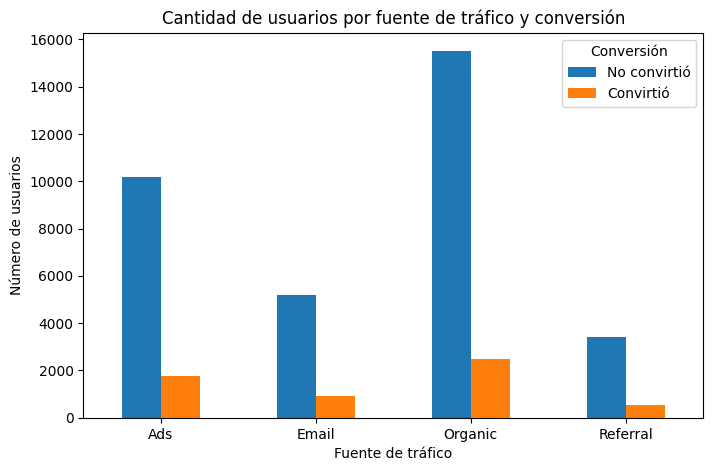

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Tabla absoluta
tabla_abs = pd.crosstab(df["traffic_source"], df["converted"])

# Gráfico barras agrupadas
tabla_abs.plot(
    kind="bar",
    stacked=False,
    figsize=(8,5)
)

plt.title("Cantidad de usuarios por fuente de tráfico y conversión")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Número de usuarios")
plt.legend(["No convirtió", "Convirtió"], title="Conversión")
plt.xticks(rotation=0)
plt.show()

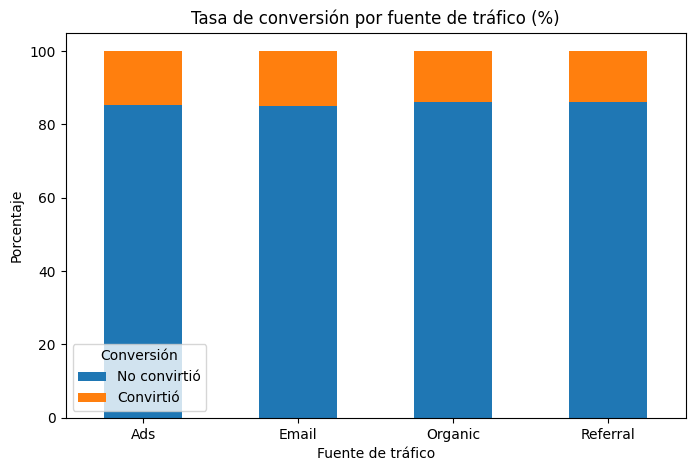

In [ ]:
# Tabla de proporciones
tabla_prop = pd.crosstab(
    df["traffic_source"],
    df["converted"],
    normalize="index"
) * 100

# Gráfico barras apiladas 100%
tabla_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Tasa de conversión por fuente de tráfico (%)")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Porcentaje")
plt.legend(["No convirtió", "Convirtió"], title="Conversión")
plt.xticks(rotation=0)
plt.show()

**Comentario** Se observa que la fuente Organic concentra la mayor cantidad de usuarios y conversiones, seguida de Ads. Sin embargo, estas diferencias se explican principalmente por el volumen de tráfico y no necesariamente por una mayor efectividad en la conversión.

✍️ **Comentario:**  
Las tasas de conversión son muy similares entre todas las fuentes de tráfico (alrededor del 14%–16%), lo que indica que ninguna fuente destaca significativamente en términos de conversión.

### Relación entre el tipo de usuario y la conversión

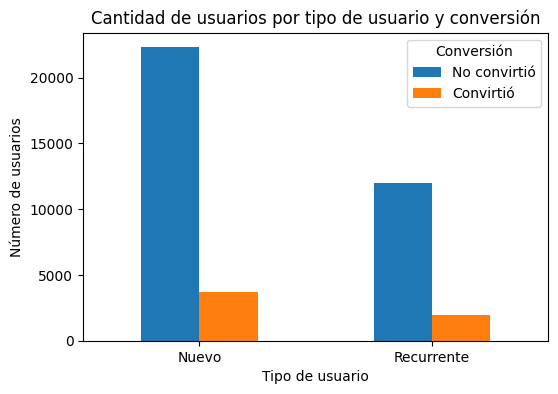

In [ ]:


# Tabla absoluta
tabla_user_abs = pd.crosstab(df["user_type"], df["converted"])

# Gráfico
tabla_user_abs.plot(
    kind="bar",
    stacked=False,
    figsize=(6,4)
)

plt.title("Cantidad de usuarios por tipo de usuario y conversión")
plt.xlabel("Tipo de usuario")
plt.ylabel("Número de usuarios")
plt.legend(["No convirtió", "Convirtió"], title="Conversión")
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario:**  
Se observa que los usuarios nuevos representan la mayor parte del tráfico y también generan más conversiones en términos absolutos. Sin embargo, esta diferencia se debe principalmente al mayor volumen de usuarios en este grupo.

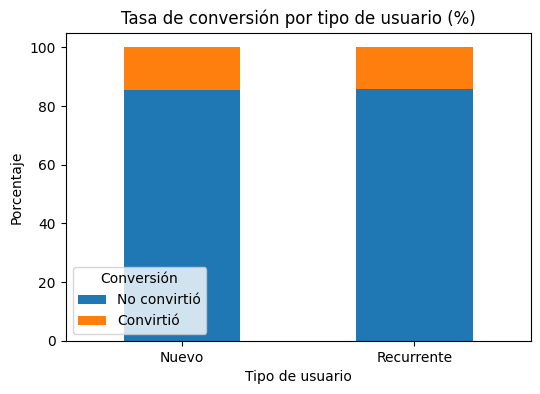


✍️ **Comentario:**  
Las tasas de conversión entre usuarios nuevos y recurrentes son muy similares, lo que indica que no hay diferencias relevantes en el desempeño de conversión entre ambos grupos.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

🌟 Insight Ejecutivo basado en el Experimento A/B

🔍 Comparación de página (A vs B)

**Gasto promedio por usuario que convirtió:**

- Observación 1: El gasto promedio entre usuarios que convierten en las páginas A y B es similar.  
- Observación 2: No se observan diferencias relevantes que indiquen que una versión genere mayor valor económico por usuario.

**Interpretación:**  
Ambas páginas tienen un comportamiento similar en términos de gasto promedio, por lo que ninguna destaca en la generación de ingresos por usuario convertido.

---

**Tasa de conversión:**

- Observación 1: La página B presenta una mayor tasa de conversión en comparación con la página A.  
- Observación 2: La diferencia observada es estadísticamente significativa, lo que indica que no es producto del azar.

**Interpretación:**  
La página B es más efectiva para convertir usuarios, por lo que representa una mejor opción en términos de desempeño del embudo de conversión.

---

📊 Segmentación por fuente de tráfico

- Observación: Las tasas de conversión entre las distintas fuentes de tráfico (Ads, Email, Organic, Referral) son muy similares.

**Interpretación:**  
No existe evidencia de que una fuente de tráfico sea significativamente más efectiva que otra en la conversión de usuarios. Las diferencias observadas se deben principalmente al volumen de tráfico.

---

📊 Segmentación por tipo de usuario

- Observación: Las tasas de conversión entre usuarios nuevos y recurrentes son prácticamente iguales.

**Interpretación:**  
No hay diferencias significativas en la conversión según el tipo de usuario, lo que sugiere que el comportamiento de conversión es consistente entre ambos grupos.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

💡 Recomendaciones de negocio:

- Implementar la página B como versión principal, ya que presenta una mayor tasa de conversión comprobada estadísticamente.  
- Mantener una estrategia de adquisición balanceada entre fuentes de tráfico, dado que no hay evidencia clara de superioridad entre ellas.  
- Explorar segmentaciones adicionales (por ejemplo, comportamiento, dispositivo o región) para identificar oportunidades de optimización más específicas.

**Link a Repositorio de GitHub**
-

-